In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)
warnings.simplefilter("ignore", ConvergenceWarning)

# 1) Dataset laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst Data Leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

df = df.sort_values("Datum").set_index("Datum")

#Target definieren
target_col = "Tagesumsatz Restaurant"

SARIMAX Model (with integrated Hyperparametertuning)

NaNs in ts: 0
NaNs in exog: weekday                                                  0
is_fr_sa                                                 0
Ferien-Value                                             0
Special-Day-Value                                        0
Niederschlag Tagessumme 6 UTC                            0
Sonnenscheindauer Tagessumme                             0
Lufttemperatur 2m Tagesmittel                            0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)    0
fourier_sin_1                                            0
fourier_cos_1                                            0
fourier_sin_2                                            0
fourier_cos_2                                            0
fourier_sin_3                                            0
fourier_cos_3                                            0
fourier_sin_4                                            0
fourier_cos_4                                            0
fourier_sin_5               

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the 

Trying order=(1, 0, 1), seasonal=(2, 1, 1, 7)


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been prov

Trying order=(1, 0, 1), seasonal=(1, 1, 2, 7)


...

c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been prov

Trying order=(1, 1, 1), seasonal=(1, 1, 2, 7)


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been prov

       order seasonal_order        MAPE           AIC
5  (2, 0, 1)   (1, 1, 2, 7)  306.379167  25823.687318
3  (2, 0, 1)   (1, 1, 1, 7)  306.985295  25821.966694
4  (2, 0, 1)   (2, 1, 1, 7)  309.160539  25822.649054
2  (1, 0, 1)   (1, 1, 2, 7)  318.283367  25762.563921
0  (1, 0, 1)   (1, 1, 1, 7)  319.762663  25748.046871

Best model: (2, 0, 1) (1, 1, 2, 7)

=== METRIKEN (mit Feiertags-Adjust) ===
MSE : 12173161.95780775
RMSE: 3489.005869557652
R2  : 0.6917744267465507
MAE : 2666.536895048603
MAPE: 24.576814905884063
Relative MSE: 0.3388788391740399


c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\klaib\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


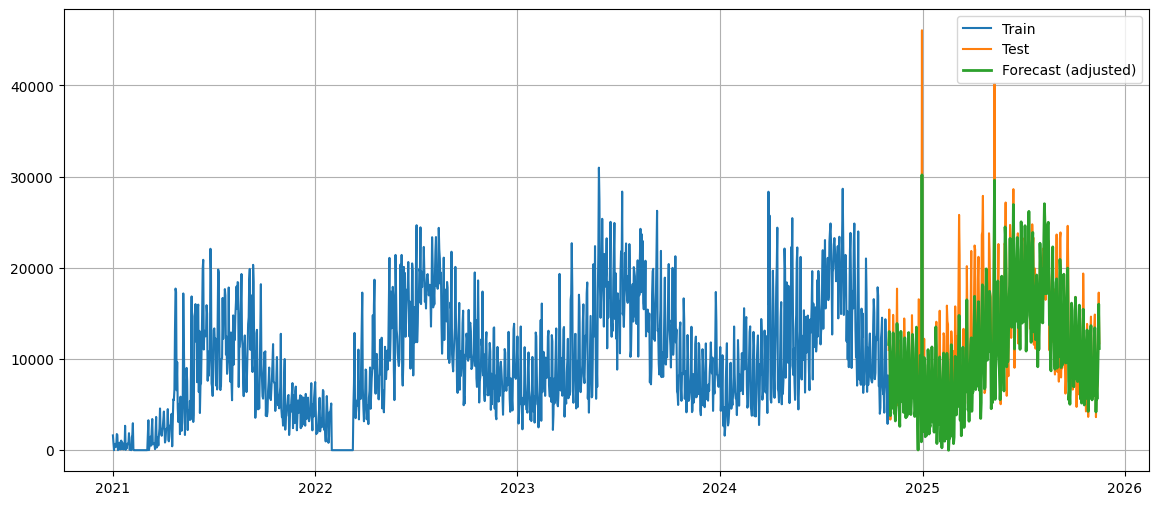

In [4]:

# ============================================================
# 1) Zielzeitreihe vorbereiten
# ============================================================

ts = df[target_col].asfreq("D")
ts = pd.to_numeric(ts, errors="coerce")
ts = ts.ffill().bfill()

# ============================================================
# 2) EXOGENE VARIABLEN (inkl. Fourier-Seasonality)
# ============================================================

exog = pd.DataFrame(index=df.index)

# 2.1 Weekday
if "Tag" in df.columns:
    mapping = {"Mo": 0, "Di": 1, "Mi": 2, "Do": 3, "Fr": 4, "Sa": 5, "So": 6}
    exog["weekday"] = df["Tag"].map(mapping)
else:
    exog["weekday"] = df.index.weekday

# 2.2 is_fr_sa
if "is_fr_sa" in df.columns:
    exog["is_fr_sa"] = df["is_fr_sa"]
else:
    exog["is_fr_sa"] = ((df.index.weekday >= 5) | (df.index.weekday == 4)).astype(int)

# 2.3 Weitere Features
feature_cols = [
    "Ferien-Value",
    "Special-Day-Value",
    "Niederschlag Tagessumme 6 UTC",
    "Sonnenscheindauer Tagessumme",
    "Lufttemperatur 2m Tagesmittel",
    "Durchschnittliche Anzahl Geburtstage (über 100 Jahre)"
]

for col in feature_cols:
    if col in df.columns:
        exog[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        exog[col] = 0.0

# 2.4 Fourier Jahres-Seasonality
def make_fourier_features(index, period=365.25, K=7):
    df_fourier = pd.DataFrame(index=index)
    t = index.dayofyear.values.astype(float)

    for k in range(1, K+1):
        df_fourier[f"fourier_sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        df_fourier[f"fourier_cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return df_fourier

fourier_df = make_fourier_features(exog.index, K=16)
exog = pd.concat([exog, fourier_df], axis=1)

# Exog bereinigen
exog = exog.asfreq("D")
exog = exog.replace([np.inf, -np.inf], np.nan)
exog = exog.ffill().bfill()

print("NaNs in ts:", ts.isna().sum())
print("NaNs in exog:", exog.isna().sum())

# ============================================================
# 3) TRAIN / TEST SPLIT
# ============================================================

split_date = pd.Timestamp("2024-11-01")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

exog_train = exog.loc[train.index]
exog_test  = exog.loc[test.index]

print("Train length (inkl. Spezialtage):", len(train))

# ============================================================
# 3b) Weihnachten / Silvester / Muttertag aus TRAIN entfernen
# ============================================================

train_dates = train.index
special_mask = pd.Series(train_dates).apply(is_special_day).values

train = train[~special_mask]
exog_train = exog_train[~special_mask]

print("Train length (ohne Spezialtage):", len(train))
print("Test length:", len(test))

# ============================================================
# 4) MAPE
# ============================================================

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ============================================================
# 5) GRID SEARCH (SARIMAX)
# ============================================================

candidate_orders = [(1,0,1), (2,0,1), (1,1,1)]
candidate_seasonal_orders = [(1,1,1,7), (2,1,1,7), (1,1,2,7)]
results = []

for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:
        try:
            print(f"Trying order={order}, seasonal={seasonal_order}")

            model = SARIMAX(
                train,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=True,
                enforce_invertibility=True
            )

            fit = model.fit(disp=False)

            tmp_forecast = fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean

            mse_tmp = mean_squared_error(test, tmp_forecast)
            mape_tmp = mape(test, tmp_forecast)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "MAPE": mape_tmp,
                "AIC": fit.aic
            })

        except Exception as e:
            print("Error:", e)

results_df = pd.DataFrame(results).sort_values("MAPE")
print(results_df.head())

best = results_df.iloc[0]
best_order = tuple(best["order"])
best_seasonal = tuple(best["seasonal_order"])

print("\nBest model:", best_order, best_seasonal)

# ============================================================
# 6) FIT FINAL MODEL
# ============================================================

final_model = SARIMAX(
    train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=True,
    enforce_invertibility=True
)
final_fit = final_model.fit(disp=False)

forecast_raw = final_fit.get_forecast(steps=len(test), exog=exog_test).predicted_mean

# ============================================================
# 7) FEIERTAGS-ADJUST
# ============================================================

forecast_adjusted = forecast_raw.values.copy()
test_dates = test.index

df_full = df.copy()
if "Datum" not in df_full.columns:
    df_full = df_full.reset_index().rename(columns={"index": "Datum"})

for i, d in enumerate(test_dates):
    d_ts = pd.Timestamp(d)
    year = d_ts.year

    # Weihnachten
    if is_christmas(d_ts):
        avg_xmas = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,24), year, target_col)
        if avg_xmas is not None:
            forecast_adjusted[i] = avg_xmas

    # Silvester
    if is_silvester(d_ts):
        avg_silvester = holiday_average_last_3_years(df_full, lambda y: pd.Timestamp(y,12,31), year, target_col)
        if avg_silvester is not None:
            forecast_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d_ts):
        avg_mothers = holiday_average_last_3_years(df_full, mothers_day, year, target_col)
        if avg_mothers is not None:
            forecast_adjusted[i] = avg_mothers

forecast_adjusted = pd.Series(forecast_adjusted, index=test.index)

# ============================================================
# 8) METRIKEN
# ============================================================

mse  = mean_squared_error(test, forecast_adjusted)
rmse = np.sqrt(mse)
r2   = r2_score(test, forecast_adjusted)
mae  = mean_absolute_error(test, forecast_adjusted)
mape_val = mape(test, forecast_adjusted)

y_naive = test.shift(1).bfill()
mse_naive = mean_squared_error(test, y_naive)
rel_mse = mse / mse_naive

print("\n=== METRIKEN (mit Feiertags-Adjust) ===")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)
print("MAE :", mae)
print("MAPE:", mape_val)
print("Relative MSE:", rel_mse)

# ============================================================
# 9) PLOTS
# ============================================================

plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_adjusted, label="Forecast (adjusted)", linewidth=2)
plt.legend()
plt.grid()
plt.show()
